# Set-Up
Package and data importing

In [ ]:
# essential package imports
import pandas as pd
from data_analysis import combine_pipeline_csvs_to_lexical_master, clean_and_prepare_lexical_df
from visualization import *

In [2]:
# read in data file as pandas dataframe
# raw_text is excluded via usecols to cut down read time
COLS_TO_LOAD = [
    'utterance_id',
    'speaker_id',
    'timestamp',
    'num_utterances_by_speaker',
    'num_utterances_by_speaker_month',
    'post_depth',
    'score',
    'num_direct_replies',
    'mtld_score',
    'mattr_score',
    'yules_k',
    'zipf_score',
    'aoa_score',
    'nawl_ratio',
    'source_variation',
    'subreddit',
]

METRICS = ['mtld_score', 'mattr_score', 'yules_k', 'zipf_score', 'aoa_score', 'nawl_ratio']

df = pd.read_csv(
    '/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/lexical_master.csv',
    usecols=COLS_TO_LOAD,
)

df = clean_and_prepare_lexical_df(df)

# User Frequency Analysis
Examine how user post frequency impacts lexical quality

## Posting Frequency Distribution Analysis
Examine the skew of speaker post-count distribution to motivate bin selection strategy.

In [ ]:
from userfreq_analysis import summarize_freq_distribution, plot_freq_distribution, diagnose_quartile_bins

summarize_freq_distribution(df)

=== Speaker Post-Count Distribution ===
  N speakers      :    3,915,835
  Mean            :         9.93
  Median          :         2.00
  Std dev         :       120.05
  Skewness        :       114.35  (>1 = right-skewed)
  Excess kurtosis :     23358.19
  Min / Max       :      1 / 46,231

=== Percentiles ===
  P    1  :         1 posts
  P    5  :         1 posts
  P   10  :         1 posts
  P   25  :         1 posts
  P   50  :         2 posts
  P   75  :         4 posts
  P   90  :        12 posts
  P   95  :        26 posts
  P   99  :       122 posts
  P 99.9  :       809 posts

=== Low-Count Speaker Breakdown ===
  <=  1 post(s)  : 45.7% of speakers
  <=  2 post(s)  : 61.4% of speakers
  <=  3 post(s)  : 70.0% of speakers
  <=  5 post(s)  : 79.2% of speakers
  <= 10 post(s)  : 88.3% of speakers


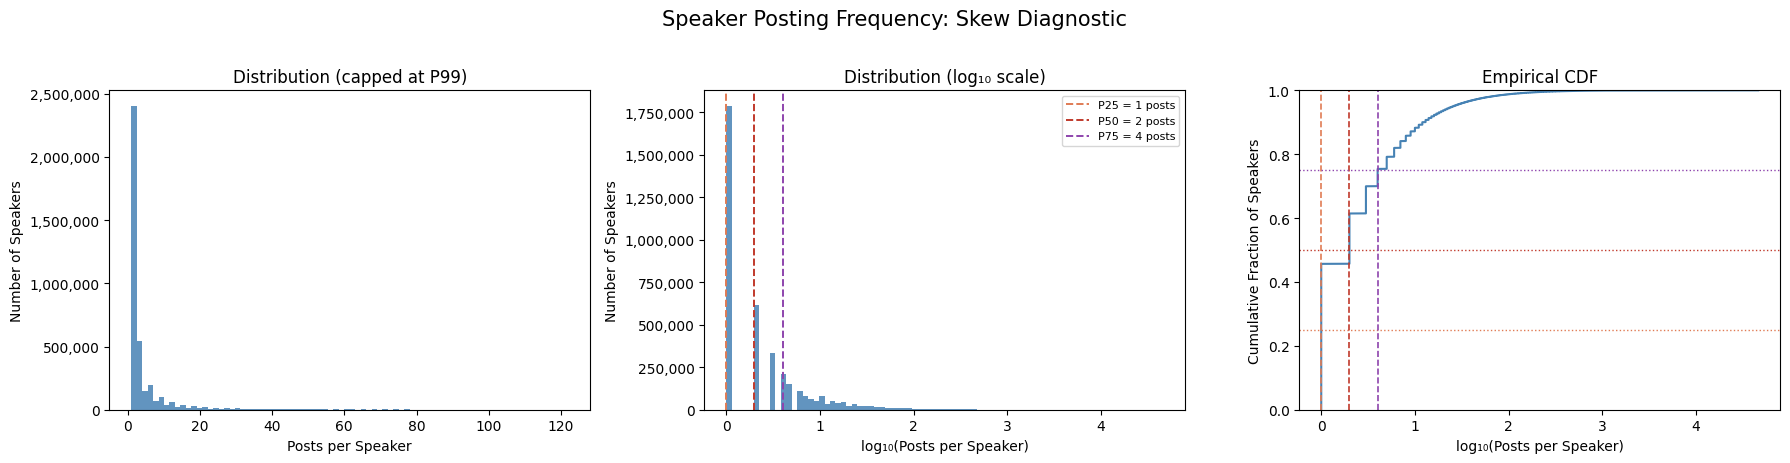

In [ ]:
plot_freq_distribution(df)

## Data Prep

In [18]:
from userfreq_analysis import assign_freq_quartiles, prepare_panel

# For Analysis 2 (all speakers, no temporal filter)
df_q = assign_freq_quartiles(df)

# For Analysis 1 (speakers with >= min_obs monthly rows only)
panel = prepare_panel(df, min_obs=3)

Retained 1,401,807 / 3,901,572 speakers (35.9%) with >= 3 monthly observations.


## Initial Visualization

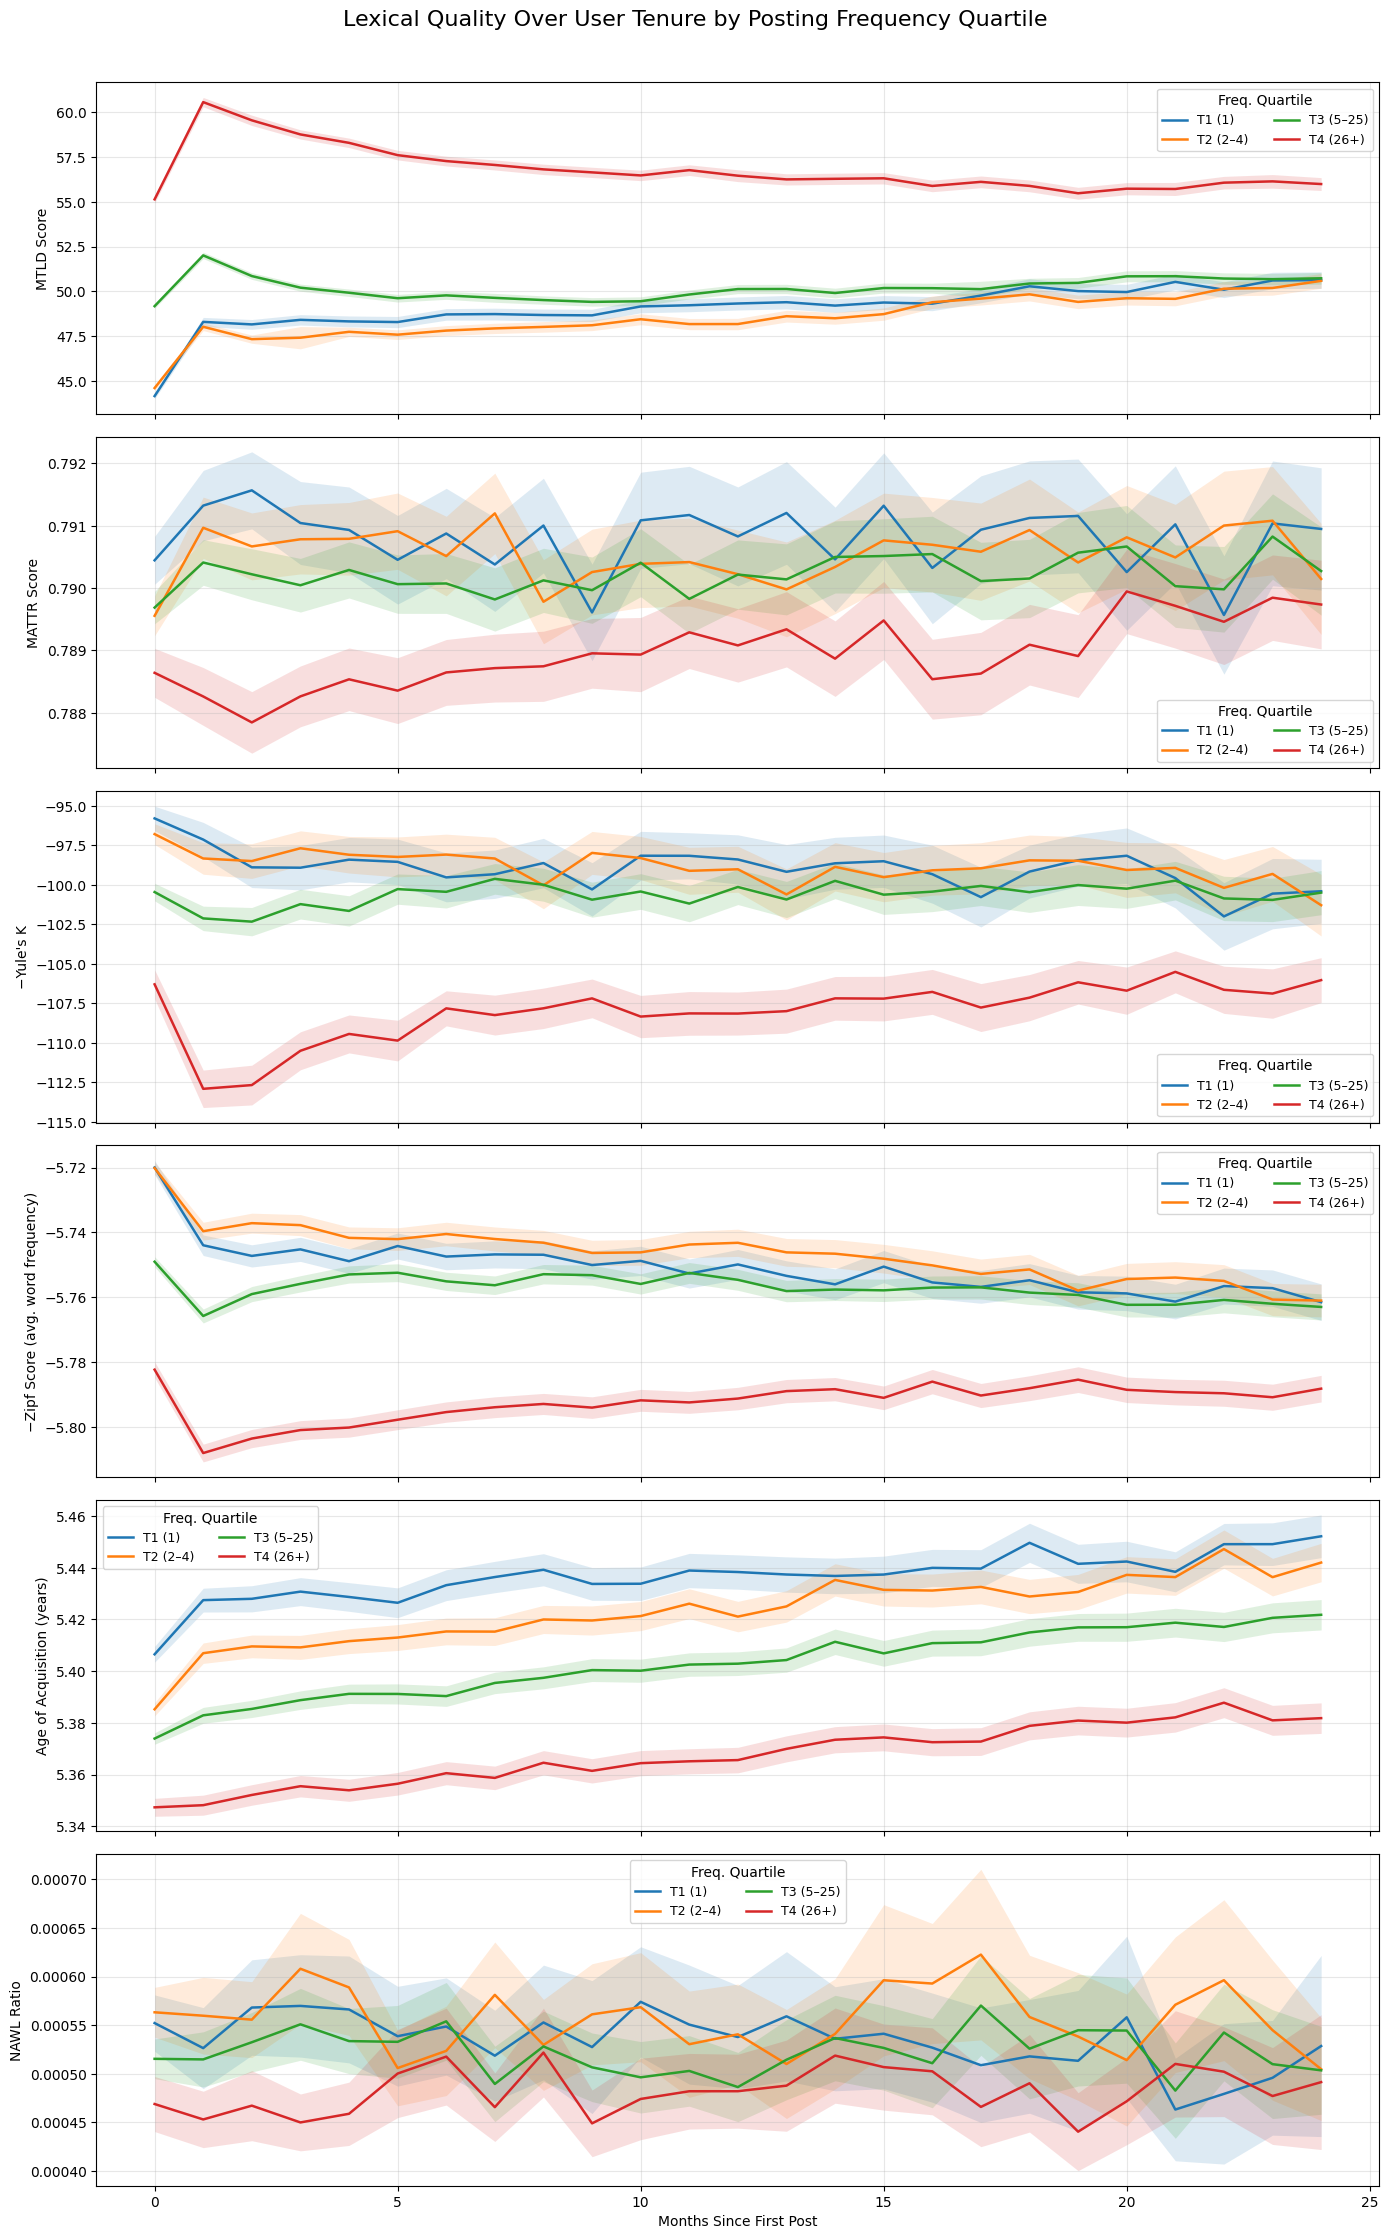

In [19]:
from userfreq_analysis import plot_quality_over_relative_time

plot_quality_over_relative_time(panel, max_relative_month=24)

## Analysis 2

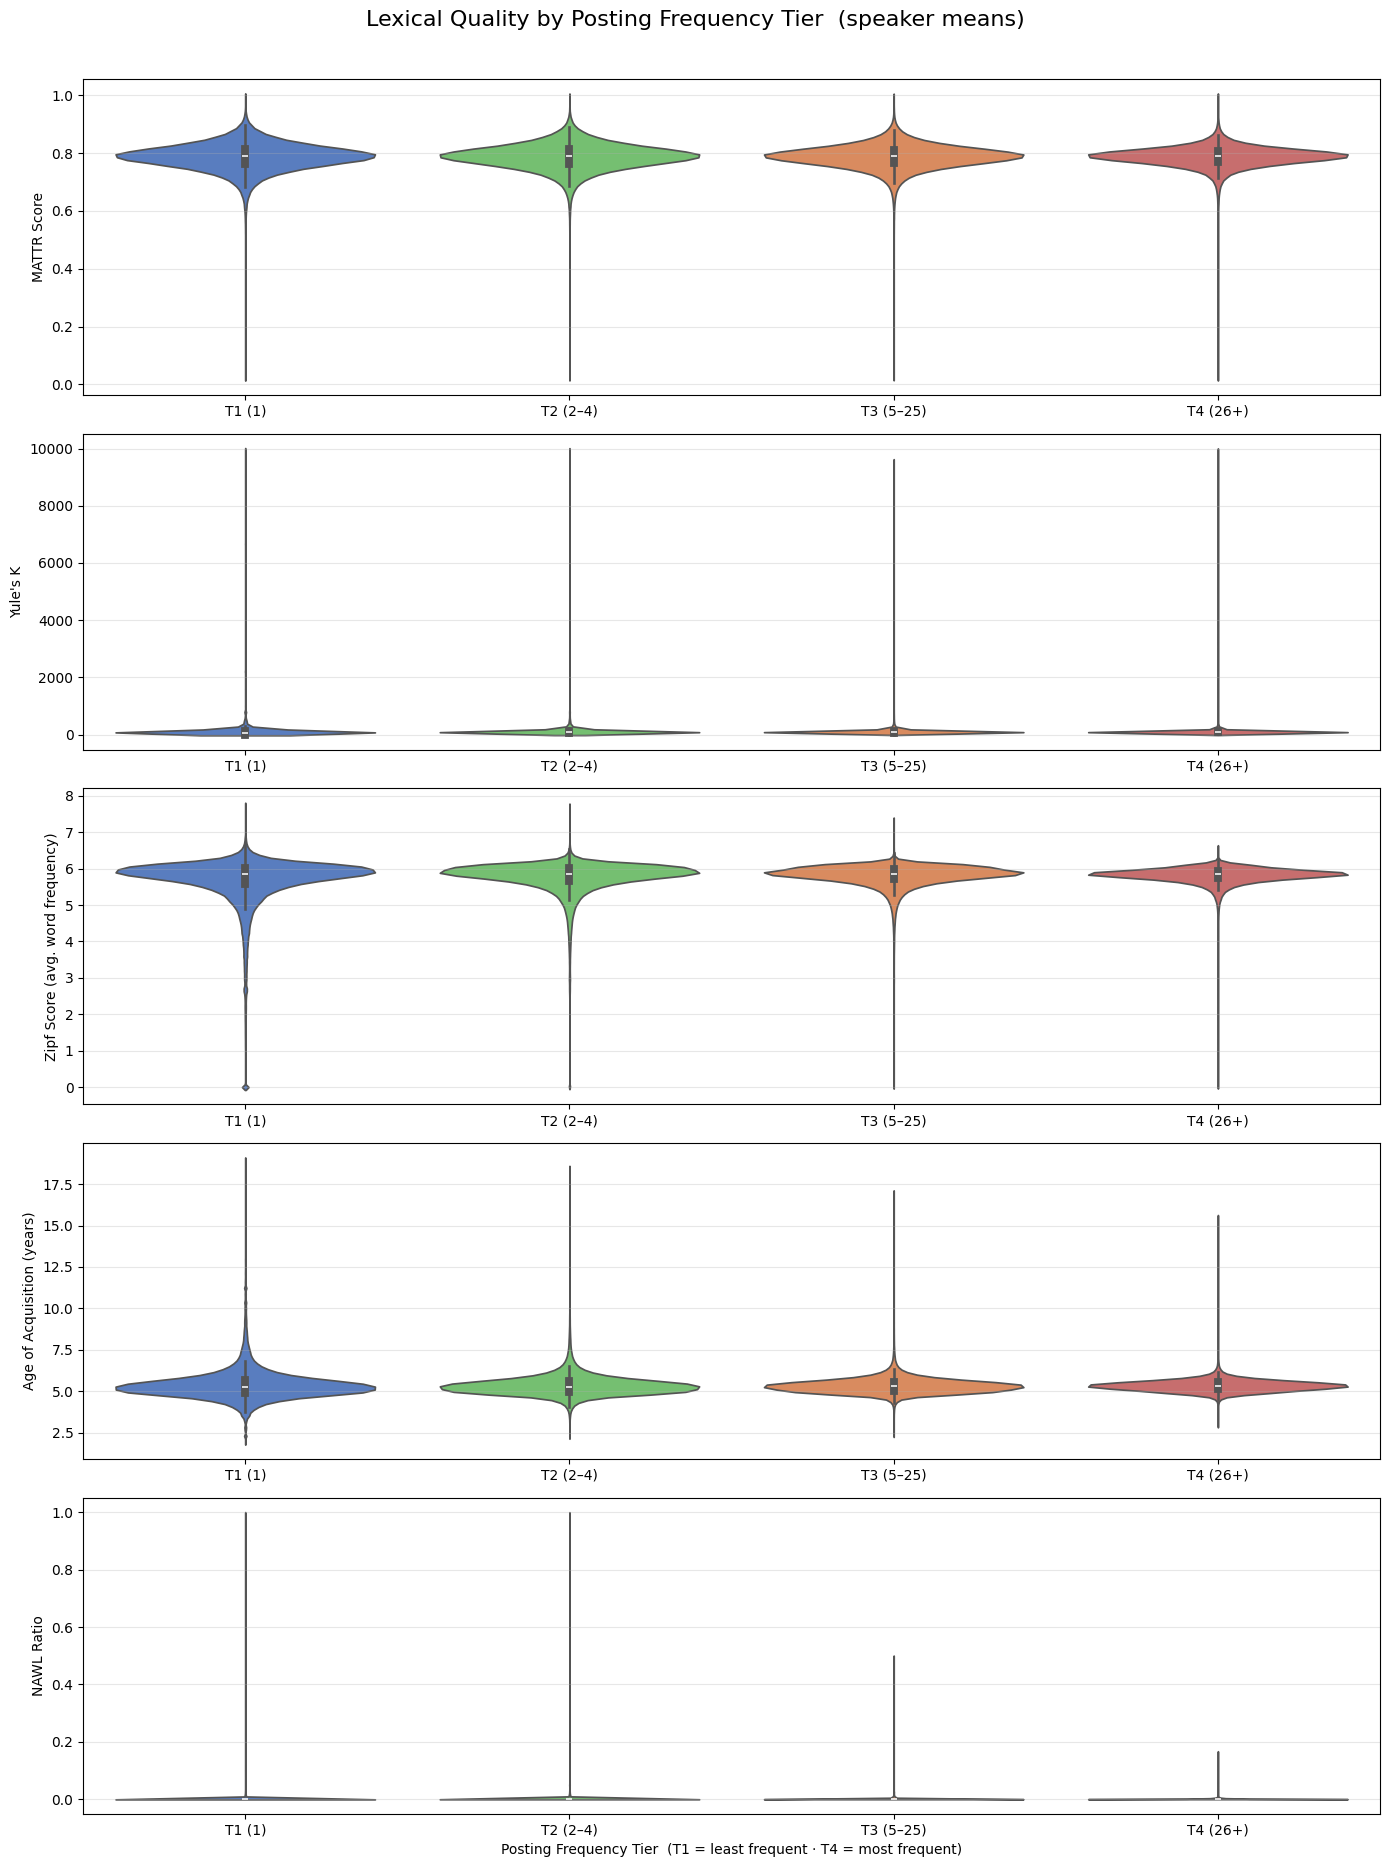

In [ ]:
from userfreq_analysis import plot_quality_by_freq_quartile, run_freq_quartile_tests

plot_quality_by_freq_quartile(df_q, kind='violin')   # or kind='box'
results = run_freq_quartile_tests(df_q)

In [ ]:
from userfreq_analysis import compute_effect_sizes, plot_effect_size_heatmap

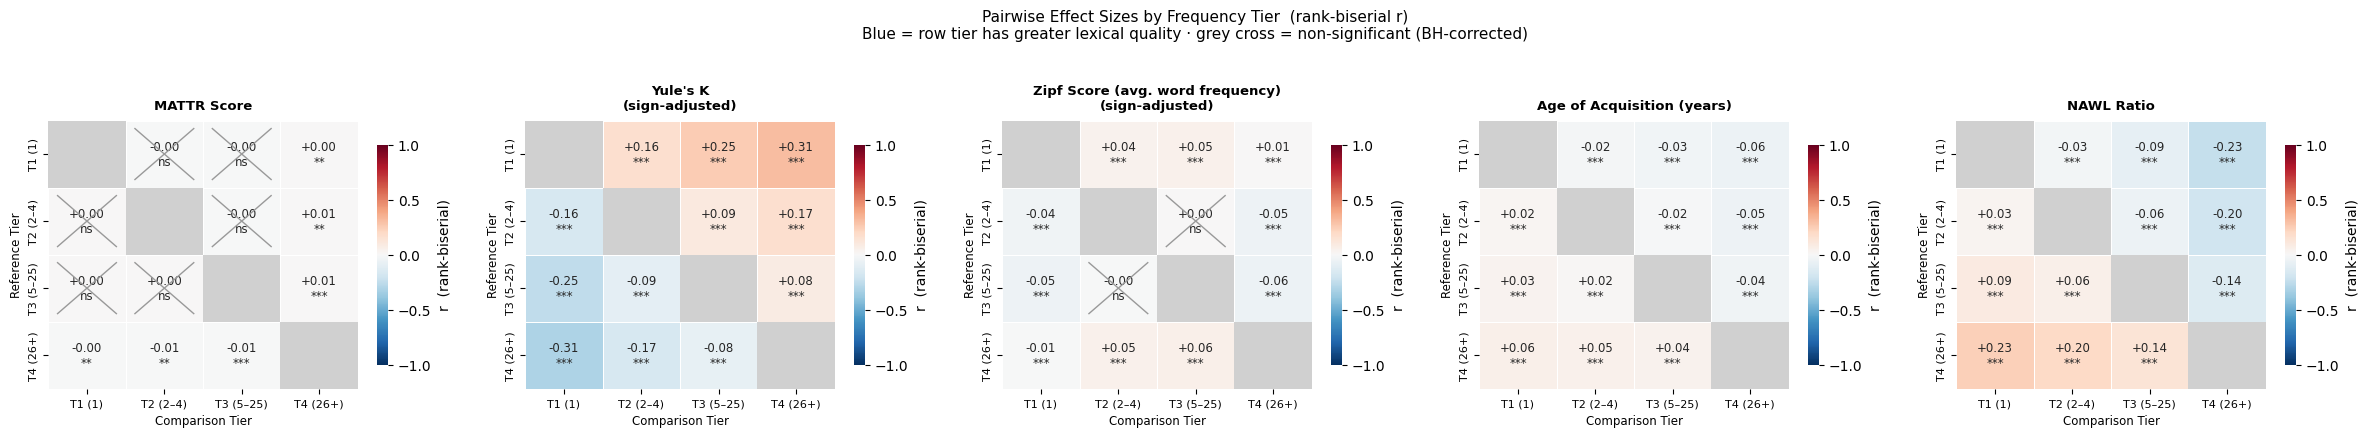

In [ ]:
# Tidy table — display directly in the notebook
es = compute_effect_sizes(df_q)
es  # shows metric, group_1, group_2, r, magnitude, p_adjusted, significant

In [ ]:
# Heatmap — one panel per metric
plot_effect_size_heatmap(df_q)

## OLS Regression

# Comparative Analysis
Examine how subreddits differ, if at all